In [3]:
import wfdb
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Point to your newly converted folder
data_dir = 'samitrop_wfdb/'

# Get a list of all record names (ignoring the .hea extension)
records = [f.replace('.hea', '') for f in glob.glob(os.path.join(data_dir, '*.hea'))]
records.sort()

print(f"Successfully found {len(records)} records!")

Successfully found 1631 records!


=== Metadata for Record: 100726 ===
Sampling frequency: 400 Hz
Number of leads: 12
Signal length: 2934 samples
Comments: ['Age: 64', 'Sex: Male', 'Chagas label: True', 'Source: SaMi-Trop']


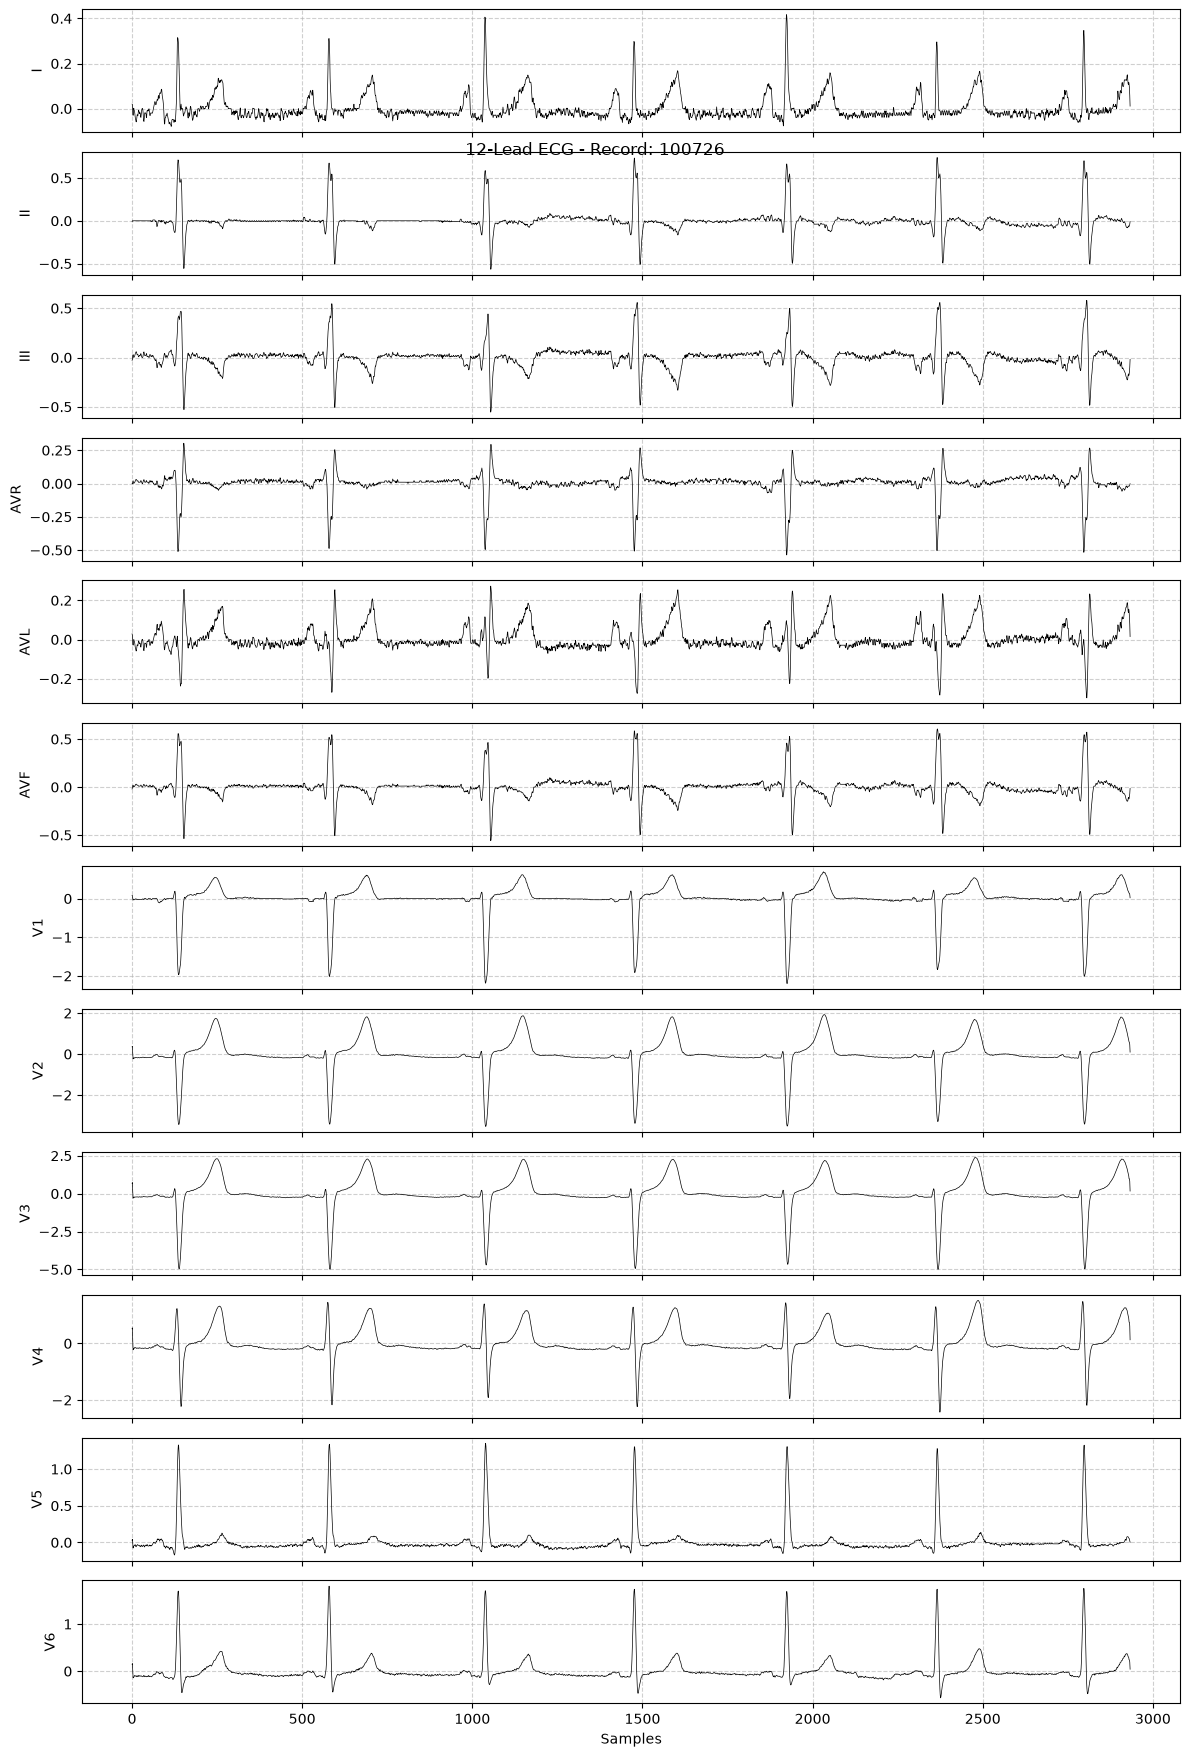

In [4]:
if records:
    # Load the very first record
    record_path = records[0]
    record = wfdb.rdrecord(record_path)

    # Print the required Metadata
    print(f"=== Metadata for Record: {record.record_name} ===")
    print(f"Sampling frequency: {record.fs} Hz")
    print(f"Number of leads: {record.n_sig}")
    print(f"Signal length: {record.sig_len} samples")
    print(f"Comments: {record.comments}")

    # Plot all 12 leads
    fig, axes = plt.subplots(12, 1, figsize=(12, 18), sharex=True)
    
    for i in range(12):
        if i < record.n_sig:
            axes[i].plot(record.p_signal[:, i], linewidth=0.5, color='black')
            axes[i].set_ylabel(record.sig_name[i])
            axes[i].grid(True, linestyle='--', alpha=0.6)
        
    axes[-1].set_xlabel('Samples')
    plt.suptitle(f'12-Lead ECG - Record: {record.record_name}', y=0.9)
    plt.tight_layout()
    plt.show()
else:
    print("Uh oh, no records found. Check your folder path!")

In [5]:
metadata_list = []

# Loop through the first 20 records
for rec_path in records[:20]:
    try:
        rec = wfdb.rdrecord(rec_path)
        
        # Parse Age and Sex from the comments array
        age, sex = "Unknown", "Unknown"
        for comment in rec.comments:
            if 'Age' in comment or 'age' in comment.lower():
                age = comment.split(':')[-1].strip()
            elif 'Sex' in comment or 'sex' in comment.lower():
                sex = comment.split(':')[-1].strip()

        # Add to our list
        metadata_list.append({
            'Record': rec.record_name,
            'Sampling Freq (Hz)': rec.fs,
            'Leads': rec.n_sig,
            'Length (samples)': rec.sig_len,
            'Age': age,
            'Sex': sex
        })
    except Exception as e:
        print(f"Error reading {rec_path}: {e}")

# Convert to Pandas DataFrame and display
df_metadata = pd.DataFrame(metadata_list)
print("\n=== 20-Record Metadata Table ===")
display(df_metadata)


=== 20-Record Metadata Table ===


,Record,Sampling Freq (Hz),Leads,Length (samples),Age,Sex
0,100726,400,12,2934,64,Male
1,101191,400,12,2934,49,Male
2,101193,400,12,2934,68,Female
3,101282,400,12,2934,70,Female
4,101842,400,12,2934,49,Female
5,102640,400,12,2934,72,Female
6,103042,400,12,2934,48,Female
7,103725,400,12,2934,74,Female
8,104023,400,12,2934,85,Female
9,105406,400,12,2934,76,Female
